In [1]:
from pathlib import Path
import sys, os, json, io, hashlib, contextlib, inspect
from datetime import datetime, timezone
from dataclasses import asdict
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'ai_data_scientist').is_dir())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark' / 'projects')
import nbformat
import pandas as pd
import numpy as np
from IPython.display import display
from ai_data_scientist import project_manager, lifecycle, language_router
RUN_ID = 'v020-exp-12'
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-12-anscombe')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
print('language:', language_router.detect_language('要約統計と可視化を比較し、日本語で説明してください。'))
events = []
@contextlib.contextmanager
def phase(name, writing=False):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行取消要求を検出しました。')
    start = lifecycle.mark_write_start if writing else lifecycle.mark_execution_start
    end = lifecycle.mark_write_end if writing else lifecycle.mark_execution_end
    start(RUN_ID)
    events.append({'phase': name, 'event': 'start', 'utc': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        events.append({'phase': name, 'event': 'failed'})
        raise
    finally:
        end(RUN_ID)
        events.append({'phase': name, 'event': 'end', 'utc': datetime.now(timezone.utc).isoformat()})
def write_notebook(mutation):
    with phase('notebook-write', writing=True):
        return project_manager.enqueue_write(handle, mutation)
def add_markdown(tag, text):
    def mutate(nb):
        matches = [c for c in nb.cells if c.metadata.get('report_tag') == tag]
        if matches:
            matches[0].source = text
        else:
            nb.cells.append(nbformat.v4.new_markdown_cell(text, metadata={'report_tag': tag}))
    write_notebook(mutate)
print('run_id:', RUN_ID)
print('notebook:', handle.notebook_path)

language: ja
run_id: v020-exp-12
notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-12-anscombe/notebooks/kaggle-v020-kaggle-exp-12-anscombe.ipynb


In [2]:
# Kaggle公開カタログ検索。認証情報・例外本文は出力しない。
with phase('kaggle-discovery'):
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    private_stream = io.StringIO()
    try:
        with contextlib.redirect_stdout(private_stream), contextlib.redirect_stderr(private_stream):
            api.authenticate()
            candidates = api.dataset_list(search='anscombe')
        catalog = [{'ref': d.ref, 'title': d.title} for d in candidates]
    except Exception as exc:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Kaggle API認証または検索失敗: ' + type(exc).__name__ + '（秘密保護のため例外本文を非表示）') from None
    finally:
        private_stream.close()
    if not catalog:
        raise RuntimeError('Kaggle上で対応する公開データが見つからないため停止。外部CSVにはフォールバックしない。')
    display(pd.DataFrame(catalog))
print('SDK dataset_list_files signature:', inspect.signature(api.dataset_list_files))
print('SDK dataset_download_file signature:', inspect.signature(api.dataset_download_file))

SDK dataset_list_files signature: (dataset, page_token=None, page_size=20)
SDK dataset_download_file signature: (dataset, file_name, path=None, force=False, quiet=True, licenses=[])


,ref,title
0,carlmcbrideellis/data-anscombes-quartet,Data: Anscombe's quintet
1,jeongtw/anscombe,anscombe
2,abdoomoh/all-seaborn-built-in-datasets,All Seaborn Built-in Datasets 📊✨
3,keshariji/data-visualization-anscombes-quartet,Data Visualization (Anscombe’s Quartet)
4,ladyvivianagaray/anscombeanddatasaurusdataset-...,AnscombeAndDatasaurusDataset-lvvg
5,germanviscuso/anscombe2,Anscombe2
6,sagarchhabriya/anscombe-simple-linear-regressi...,anscombe simple linear regression dataset
7,alaaomar85/anscombes,anscombes


In [3]:
with phase('kaggle-source-inspection'):
    listing = {}
    reference_metadata = {}
    private_stream = io.StringIO()
    try:
        with contextlib.redirect_stdout(private_stream), contextlib.redirect_stderr(private_stream):
            for ref in [catalog[0]['ref'], 'jeongtw/anscombe']:
                response = api.dataset_list_files(ref, page_size=100)
                listing[ref] = [{'name': f.name, 'size': getattr(f, 'total_bytes', None)} for f in response.files]
        print(json.dumps(listing, ensure_ascii=False, indent=2))
        print('kernels_pull signature:', inspect.signature(api.kernels_pull))
    except Exception as exc:
        raise RuntimeError('Kaggleファイル一覧取得失敗: ' + type(exc).__name__) from None
    finally:
        private_stream.close()

{
  "carlmcbrideellis/data-anscombes-quartet": [
    {
      "name": "Anscombe_quartet_data.csv",
      "size": 337
    },
    {
      "name": "Anscombe_quintet_data.csv",
      "size": 391
    }
  ],
  "jeongtw/anscombe": [
    {
      "name": "ch3_anscombe.npy",
      "size": 784
    }
  ]
}
kernels_pull signature: (kernel, path, metadata=False, quiet=True)


In [4]:
with phase('kaggle-download'):
    DATASET = 'carlmcbrideellis/data-anscombes-quartet'
    FILENAME = 'Anscombe_quartet_data.csv'
    reference_dir = data_dir / 'kaggle-reference'
    reference_dir.mkdir(exist_ok=True)
    private_stream = io.StringIO()
    try:
        with contextlib.redirect_stdout(private_stream), contextlib.redirect_stderr(private_stream):
            api.kernels_pull('tomarns/anscombe-s-quartet', path=str(reference_dir), metadata=True, quiet=True)
            api.dataset_download_file(DATASET, FILENAME, path=str(data_dir), force=True, quiet=True)
    except Exception as exc:
        raise RuntimeError('Kaggle参照Notebookまたはデータ取得失敗: ' + type(exc).__name__) from None
    finally:
        private_stream.close()
    csv_path = data_dir / FILENAME
    if not csv_path.is_file():
        raise RuntimeError('指定CSVが取得できないため停止。外部ミラー不使用。')
    provenance = {'owner_dataset_slug': DATASET, 'file_name': FILENAME,
                  'retrieved_utc': datetime.now(timezone.utc).isoformat(),
                  'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(),
                  'reference_url': 'https://www.kaggle.com/code/tomarns/anscombe-s-quartet'}
    meta_path = reference_dir / 'kernel-metadata.json'
    if meta_path.exists():
        meta = json.loads(meta_path.read_text())
        reference_metadata = {k: meta.get(k) for k in ['id', 'title', 'dataset_sources', 'kernel_sources']}
    reference_files = [p for p in reference_dir.glob('*.ipynb')]
    if not reference_files:
        raise RuntimeError('参照Notebookの内容を確認できないため停止。')
    source_nb = nbformat.read(reference_files[0], as_version=4)
    reference_features = {'code_cell_count': sum(c.cell_type == 'code' for c in source_nb.cells),
                          'markdown_cell_count': sum(c.cell_type == 'markdown' for c in source_nb.cells),
                          'uses_seaborn_anscombe_loader': any('load_dataset' in c.source and 'anscombe' in c.source for c in source_nb.cells),
                          'uses_regplot': any('regplot' in c.source for c in source_nb.cells),
                          'uses_lmplot': any('lmplot' in c.source for c in source_nb.cells),
                          'mentions_correlation': any('corr' in c.source.lower() for c in source_nb.cells)}
    raw = pd.read_csv(csv_path)
    print(json.dumps({'provenance': provenance, 'reference_metadata': reference_metadata,
                      'reference_features': reference_features}, ensure_ascii=False, indent=2))
    display(raw)
    print('CSV columns:', list(raw.columns))

{
  "provenance": {
    "owner_dataset_slug": "carlmcbrideellis/data-anscombes-quartet",
    "file_name": "Anscombe_quartet_data.csv",
    "retrieved_utc": "2026-10-01T17:05:51.279178+00:00",
    "sha256": "21dd4998e5985a2717e1ca154e3f90ac7657e8e71c6564096d92addf3c5a36b9",
    "reference_url": "https://www.kaggle.com/code/tomarns/anscombe-s-quartet"
  },
  "reference_metadata": {
    "id": "tomarns/anscombe-s-quartet",
    "title": "Anscombe's Quartet",
    "dataset_sources": [],
    "kernel_sources": []
  },
  "reference_features": {
    "code_cell_count": 2,
    "markdown_cell_count": 1,
    "uses_seaborn_anscombe_loader": true,
    "uses_regplot": false,
    "uses_lmplot": false,
    "mentions_correlation": true
  }
}
CSV columns: ['x123', 'y1', 'y2', 'y3', 'x4', 'y4']


,x123,y1,y2,y3,x4,y4
0,10.0,8.04,9.14,7.46,8.0,6.58
1,8.0,6.95,8.14,6.77,8.0,5.76
2,13.0,7.58,8.74,12.74,8.0,7.71
3,9.0,8.81,8.77,7.11,8.0,8.84
4,11.0,8.33,9.26,7.81,8.0,8.47
5,14.0,9.96,8.10,8.84,8.0,7.04
6,6.0,7.24,6.13,6.08,8.0,5.25
7,4.0,4.26,3.10,5.39,19.0,12.50
8,12.0,10.84,9.13,8.15,8.0,5.56
9,7.0,4.82,7.26,6.42,8.0,7.91


# 分析計画
対象はKaggleのAnscombeの4群（各11点）。問いは「近似的に同じ平均・標本分散・Pearson相関・OLS直線でも、同じ関係構造・予測可能性と結論してよいか」。

1. Kaggle SDKで公開データを検索しファイル一覧を確認、CSVを取得してSHA-256と取得日時を記録。参照NotebookはAPIで読み、外部CSVやseaborn.load_datasetは実行しない。
2. 群・行ID・x・yの長形式へ変換。欠損、非有限値、群サイズ、列対応、重複キーを検証。繰り返すxは正当な構造として保存し、外れ値を自動削除しない。
3. 群ごとの要約統計、共通軸の散布図+OLS直線、残差対x、レバレッジ/Cook距離を比較。群IIは線形と二次モデルを比較、群III/IVは1点除去と識別可能性を確認。
4. 感度分析は全点/各1点除去、モデル次数1/2、影響点判定閾値で実施。適合誤差と予測誤差を混同しない。小標本のため検定p値のみで同等性・因果・実世界への一般化を断定しない。
5. 初回結果を読み直して未解決点を自然言語の反復依頼に保存（最大3回）。最後に全コードを上から再実行しvisual_audit=Trueとlifecycle状態を保存。

# Kaggle参照例の調査
参照: https://www.kaggle.com/code/tomarns/anscombe-s-quartet 。API取得したソースはコード2セル・説明1セルで、seabornのAnscombeローダーと相関計算を含む。dataset_sourcesは空であり、今回のCSVが参照Notebookの直接入力だとは主張しない。公開カタログで対応するQuartet CSVを別途取得し、値の構造を確認する。Quintet CSVは対象外。

# 適用範囲と適用できない機能
教育用の固定4群に対する記述・関連分析。測定単位と実際の母集団・収集機構は不明。独立した参照観測データがないためvalidate_anomaliesおよびcompare_datasetsによる外部妥当性確認は非適用（同じ教材のコピーは独立検証にならない）。ランダム標本抽出・因果同定・時系列・MLは非適用。run_and_recordは呼出側のMCPClientがこのCLIからカーネルに公開されないため直接使用せず、Jupyter MCP execute_cellで実行し実際の出力を保存する（代替実行/外部スクリプトなし）。

In [5]:
# 定義・前提・意味的品質検査（対応する計画は直前のMarkdown）。
from ai_data_scientist import ingestion, cleaning, eda, data_definition, analysis_assumptions, data_quality
from ai_data_scientist.data_definition import FieldValue
from ai_data_scientist.analysis_assumptions import Assumption, AnalysisAssumptionManifest
with phase('definitions-and-quality'):
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=100)
    raw = loaded.dataframe
    assert list(raw.columns) == ['x123', 'y1', 'y2', 'y3', 'x4', 'y4']
    assert raw.shape == (11, 6) and not loaded.truncated
    frames = []
    for i, group in enumerate(['I', 'II', 'III', 'IV'], start=1):
        frames.append(pd.DataFrame({'group': group, 'row_id': np.arange(1, 12),
                                    'x': raw['x4' if i == 4 else 'x123'], 'y': raw[f'y{i}']}))
    df = pd.concat(frames, ignore_index=True)
    clean_report = cleaning.clean_dataset(df, operation='drop_na', columns=['x', 'y'])
    assert clean_report.rows_removed == 0
    assert np.isfinite(df[['x', 'y']].to_numpy()).all()
    df['key'] = df.group + ':' + df.row_id.astype(str)
    semantic_anomalies = data_quality.detect_anomalies(df, schema={
        'group': {'allowed': ['I', 'II', 'III', 'IV'], 'not_null': True},
        'row_id': {'min': 1, 'max': 11, 'not_null': True},
        'key': {'unique': True, 'not_null': True},
        'x': {'not_null': True}, 'y': {'not_null': True}})
    assert not semantic_anomalies and df.groupby('group').size().eq(11).all()
    definitions = data_definition.build_manifest(
        source={k: FieldValue(v, 'verified', 'Kaggle SDK response/local bytes') for k, v in provenance.items()},
        dataset_scope={'purpose': FieldValue('Anscombe Quartet教材', 'inferred', '公開カタログ名・列と値の構造'),
                       'population': FieldValue(None, 'unknown'), 'measurement_process': FieldValue(None, 'unknown')},
        variables={'group': {'definition': FieldValue('I〜IV: x123/y1〜3、x4/y4の4組', 'verified', 'CSV列構造')},
                   'x': {'definition': FieldValue('説明側数値', 'inferred', '列名'), 'unit': FieldValue(None, 'unknown')},
                   'y': {'definition': FieldValue('応答側数値', 'inferred', '列名'), 'unit': FieldValue(None, 'unknown')},
                   'row_id': {'definition': FieldValue('原ファイルの1始まり行番号', 'verified', '変換コード')}},
        transformations=('wide→long; x123 reused for I/II/III; no imputation or point removal',))
    assumptions = AnalysisAssumptionManifest(
        analysis_scope={'groups': ['I', 'II', 'III', 'IV'], 'n_per_group': 11, 'variance_ddof': 1},
        causal_scope='associational',
        assumptions=(Assumption('mapping', '列組合せと各11点、有限値を保持', 'tested', conclusion_critical=True),
                     Assumption('units', 'x/yの物理単位は結論に不要', 'assumed', conclusion_critical=False),
                     Assumption('iid', '独立同分布の実測母集団標本とは扱わない', 'verified'),
                     Assumption('linear', '全4群で線形が妥当という仮説はこれから検査', 'assumed', conclusion_critical=True)))
    assumption_findings = analysis_assumptions.check_manifest(assumptions)
    definition_unknown = definitions.unresolved_fields()
    inferred_fields = [(f'{var}.{field}', asdict(v)) for var, fields in definitions.variables.items()
                       for field, v in fields.items() if v.status == 'inferred']
    print('cleaning:', {'before': clean_report.rows_before, 'after': clean_report.rows_after, 'removed': clean_report.rows_removed})
    print('semantic_anomalies:', [asdict(a) for a in semantic_anomalies])
    print('unknown fields:', [name for name, value in definition_unknown])
    print('inferred fields:', inferred_fields)
    print('assumption findings:', [asdict(a) for a in assumption_findings])
    print('EDA:', json.dumps(asdict(eda.explore(df)), ensure_ascii=False, default=str))
    display(df.head())

cleaning: {'before': 44, 'after': 44, 'removed': 0}
semantic_anomalies: []
unknown fields: ['dataset_scope.population', 'dataset_scope.measurement_process', 'variables.x.unit', 'variables.y.unit']
inferred fields: [('x.definition', {'value': '説明側数値', 'status': 'inferred', 'source': '列名'}), ('y.definition', {'value': '応答側数値', 'status': 'inferred', 'source': '列名'})]
assumption findings: [{'code': 'unresolved_conclusion_critical_assumption', 'severity': 'warning', 'message': "Conclusion-critical assumption 'linear' has status 'assumed', not verified/tested.", 'assumption_id': 'linear'}]
EDA: {"describe": {"row_id": {"count": 44.0, "mean": 6.0, "std": 3.198836997962679, "min": 1.0, "25%": 3.0, "50%": 6.0, "75%": 9.0, "max": 11.0}, "x": {"count": 44.0, "mean": 9.0, "std": 3.198836997962679, "min": 4.0, "25%": 7.0, "50%": 8.0, "75%": 11.0, "max": 19.0}, "y": {"count": 44.0, "mean": 7.500681818181818, "std": 1.958925189078419, "min": 3.1, "25%": 6.1175, "50%": 7.52, "75%": 8.7475, "max": 12.7

,group,row_id,x,y,key
0,I,1,10.0,8.04,I:1
1,I,2,8.0,6.95,I:2
2,I,3,13.0,7.58,I:3
3,I,4,9.0,8.81,I:4
4,I,5,11.0,8.33,I:5


In [6]:
# 要約統計・OLS・影響度・モデル比較の実行結果。
from ai_data_scientist import stats_analysis
from scipy import stats
with phase('initial-analysis'):
    GROUPS = ['I', 'II', 'III', 'IV']
    fits, correlations, diagnostic_frames = {}, {}, []
    def fit_polynomial(g, degree=1):
        X = np.vander(g.x.to_numpy(), N=degree + 1, increasing=True)
        rank = np.linalg.matrix_rank(X)
        if rank < degree + 1:
            return {'identifiable': False, 'rank': int(rank)}
        beta = np.linalg.lstsq(X, g.y.to_numpy(), rcond=None)[0]
        residual = g.y.to_numpy() - X @ beta
        return {'identifiable': True, 'rank': int(rank), 'X': X, 'beta': beta,
                'residual': residual, 'sse': float(residual @ residual),
                'rmse': float(np.sqrt(np.mean(residual ** 2)))}
    summary_rows, model_rows = [], []
    for group in GROUPS:
        g = df[df.group == group].copy()
        fit = fit_polynomial(g)
        fits[group] = fit
        corr = stats_analysis.correlation(g, 'x', 'y', language='ja')
        correlations[group] = corr
        summary_rows.append({'group': group, 'n': len(g), 'mean_x': g.x.mean(), 'var_x_ddof1': g.x.var(ddof=1),
                             'mean_y': g.y.mean(), 'var_y_ddof1': g.y.var(ddof=1), 'pearson_r': corr.statistic,
                             'slope': fit['beta'][1], 'intercept': fit['beta'][0],
                             'R2': 1 - fit['sse'] / ((g.y - g.y.mean()) ** 2).sum(),
                             'spearman_r': stats.spearmanr(g.x, g.y).statistic, 'unique_x': g.x.nunique()})
        X = fit['X']
        h = np.sum(X * np.linalg.pinv(X).T, axis=1)
        mse = fit['sse'] / (len(g) - X.shape[1])
        valid_cook = (1 - h) > 1e-10
        cooks = np.full(len(g), np.nan)
        cooks[valid_cook] = (fit['residual'][valid_cook] ** 2 / (X.shape[1] * mse)) * h[valid_cook] / (1 - h[valid_cook]) ** 2
        diagnostics = g[['group', 'row_id', 'x', 'y']].copy()
        diagnostics['residual'] = fit['residual']
        diagnostics['leverage'] = h
        diagnostics['cook_distance'] = cooks
        diagnostics['cook_defined'] = valid_cook
        diagnostic_frames.append(diagnostics)
        for degree in [1, 2]:
            model = fit_polynomial(g, degree)
            if not model['identifiable']:
                model_rows.append({'group': group, 'degree': degree, 'identifiable': False,
                                   'train_rmse': np.nan, 'loocv_rmse': np.nan, 'invalid_folds': len(g)})
                continue
            fold_errors, invalid = [], 0
            for position in range(len(g)):
                train, test = g.drop(g.index[position]), g.iloc[position]
                fold = fit_polynomial(train, degree)
                if not fold['identifiable']:
                    invalid += 1
                else:
                    pred = np.array([test.x ** d for d in range(degree + 1)]) @ fold['beta']
                    fold_errors.append(float((test.y - pred) ** 2))
            model_rows.append({'group': group, 'degree': degree, 'identifiable': True,
                               'train_rmse': model['rmse'],
                               'loocv_rmse': np.sqrt(np.mean(fold_errors)) if invalid == 0 else np.nan,
                               'invalid_folds': invalid})
    summary = pd.DataFrame(summary_rows).set_index('group')
    diagnostics = pd.concat(diagnostic_frames, ignore_index=True)
    models = pd.DataFrame(model_rows)
    display(summary.round(9))
    display(models.round(9))
    display(diagnostics.sort_values('leverage', ascending=False).head(8))
    initial_evidence = {'summary': summary.reset_index().to_dict('records'), 'models': models.to_dict('records'),
                        'max_leverage_IV': diagnostics[diagnostics.group == 'IV'].leverage.max(),
                        'max_cook_III': diagnostics[diagnostics.group == 'III'].cook_distance.max()}
    display({'text/plain': json.dumps(initial_evidence, ensure_ascii=False)}, raw=True)
    print('相関の解釈（仮定が成立しなければ一般化不可）:', {g: r.interpretation for g, r in correlations.items()})

相関の解釈（仮定が成立しなければ一般化不可）: {'I': '相関係数は 0.8164 (p=0.00217) で、強い正の相関が見られます。', 'II': '相関係数は 0.8162 (p=0.002179) で、強い正の相関が見られます。', 'III': '相関係数は 0.8163 (p=0.002176) で、強い正の相関が見られます。', 'IV': '相関係数は 0.8165 (p=0.002165) で、強い正の相関が見られます。'}


,n,mean_x,var_x_ddof1,mean_y,var_y_ddof1,pearson_r,slope,intercept,R2,spearman_r,unique_x
group,,,,,,,,,,,
I,11,9.0,11.0,7.500909,4.127269,0.816421,0.500091,3.000091,0.666542,0.818182,11
II,11,9.0,11.0,7.500909,4.127629,0.816237,0.500000,3.000909,0.666242,0.690909,11
III,11,9.0,11.0,7.500000,4.122620,0.816287,0.499727,3.002455,0.666324,0.990909,11
IV,11,9.0,11.0,7.500909,4.123249,0.816521,0.499909,3.001727,0.666707,0.500000,2


,group,degree,identifiable,train_rmse,loocv_rmse,invalid_folds
0,I,1,True,1.118550,1.367787,0
1,I,2,True,1.083128,1.398117,0
2,II,1,True,1.119102,1.484648,0
3,II,2,True,0.001426,0.001764,0
4,III,1,True,1.118286,1.465390,0
5,III,2,True,1.087069,1.762707,0
6,IV,1,True,1.117729,NaN,1
7,IV,2,False,NaN,NaN,11


,group,row_id,x,y,residual,leverage,cook_distance,cook_defined
40,IV,8,19.0,12.50,-3.552714e-15,1.000000,NaN,False
5,I,6,14.0,9.96,-4.136364e-02,0.318182,0.000383,True
16,II,6,14.0,8.10,-1.900909e+00,0.318182,0.807869,True
27,III,6,14.0,8.84,-1.158636e+00,0.318182,0.300571,True
18,II,8,4.0,3.10,-1.900909e+00,0.318182,0.807869,True
7,I,8,4.0,4.26,-7.404545e-01,0.318182,0.122700,True
29,III,8,4.0,5.39,3.886364e-01,0.318182,0.033817,True
13,II,3,13.0,8.74,-7.609091e-01,0.236364,0.076657,True


{"summary": [{"group": "I", "n": 11, "mean_x": 9.0, "var_x_ddof1": 11.0, "mean_y": 7.500909090909093, "var_y_ddof1": 4.127269090909091, "pearson_r": 0.8164205163448395, "slope": 0.5000909090909091, "intercept": 3.000090909090907, "R2": 0.666542459508775, "spearman_r": 0.8181818181818182, "unique_x": 11}, {"group": "II", "n": 11, "mean_x": 9.0, "var_x_ddof1": 11.0, "mean_y": 7.50090909090909, "var_y_ddof1": 4.127629090909091, "pearson_r": 0.8162365060002424, "slope": 0.5000000000000002, "intercept": 3.0009090909090874, "R2": 0.6662420337274844, "spearman_r": 0.690909090909091, "unique_x": 11}, {"group": "III", "n": 11, "mean_x": 9.0, "var_x_ddof1": 11.0, "mean_y": 7.5, "var_y_ddof1": 4.12262, "pearson_r": 0.8162867394895981, "slope": 0.499727272727273, "intercept": 3.002454545454544, "R2": 0.6663240410665591, "spearman_r": 0.990909090909091, "unique_x": 11}, {"group": "IV", "n": 11, "mean_x": 9.0, "var_x_ddof1": 11.0, "mean_y": 7.500909090909091, "var_y_ddof1": 4.123249090909091, "pears

chart metadata: {"scatter": {"title": "Anscombe quartet: same summary, different geometry", "xlabel": "x (unit unknown)", "ylabel": "y (unit unknown)", "legend": ["Observed", "OLS linear", "Quadratic (II)"], "missing_glyphs": [], "bytes": 149924}, "residual": {"title": "OLS residuals", "xlabel": "x (unit unknown)", "ylabel": "y - fitted y", "legend": ["OLS residual", "Zero residual"], "missing_glyphs": [], "bytes": 94760}, "influence": {"title": "Influence diagnostic", "xlabel": "Leverage h", "ylabel": "OLS residual", "legend": ["Size: Cook distance", "h=1 undefined", "Leverage 2p/n"], "missing_glyphs": [], "bytes": 105632}}


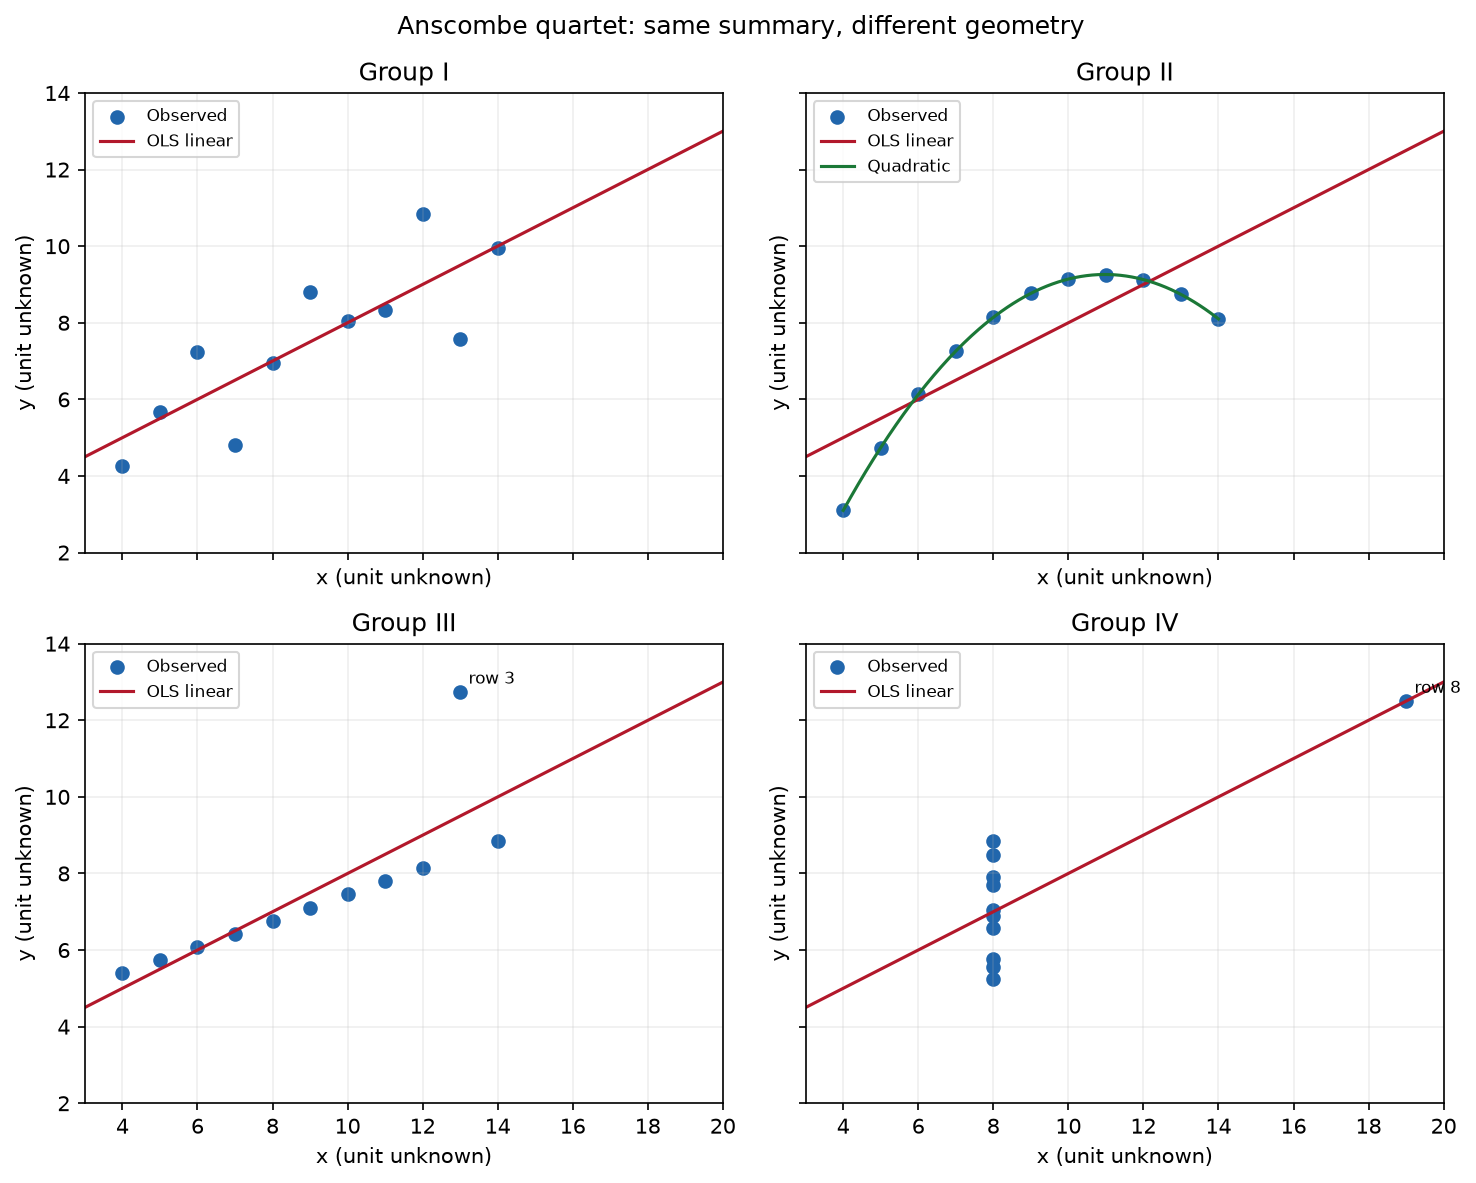

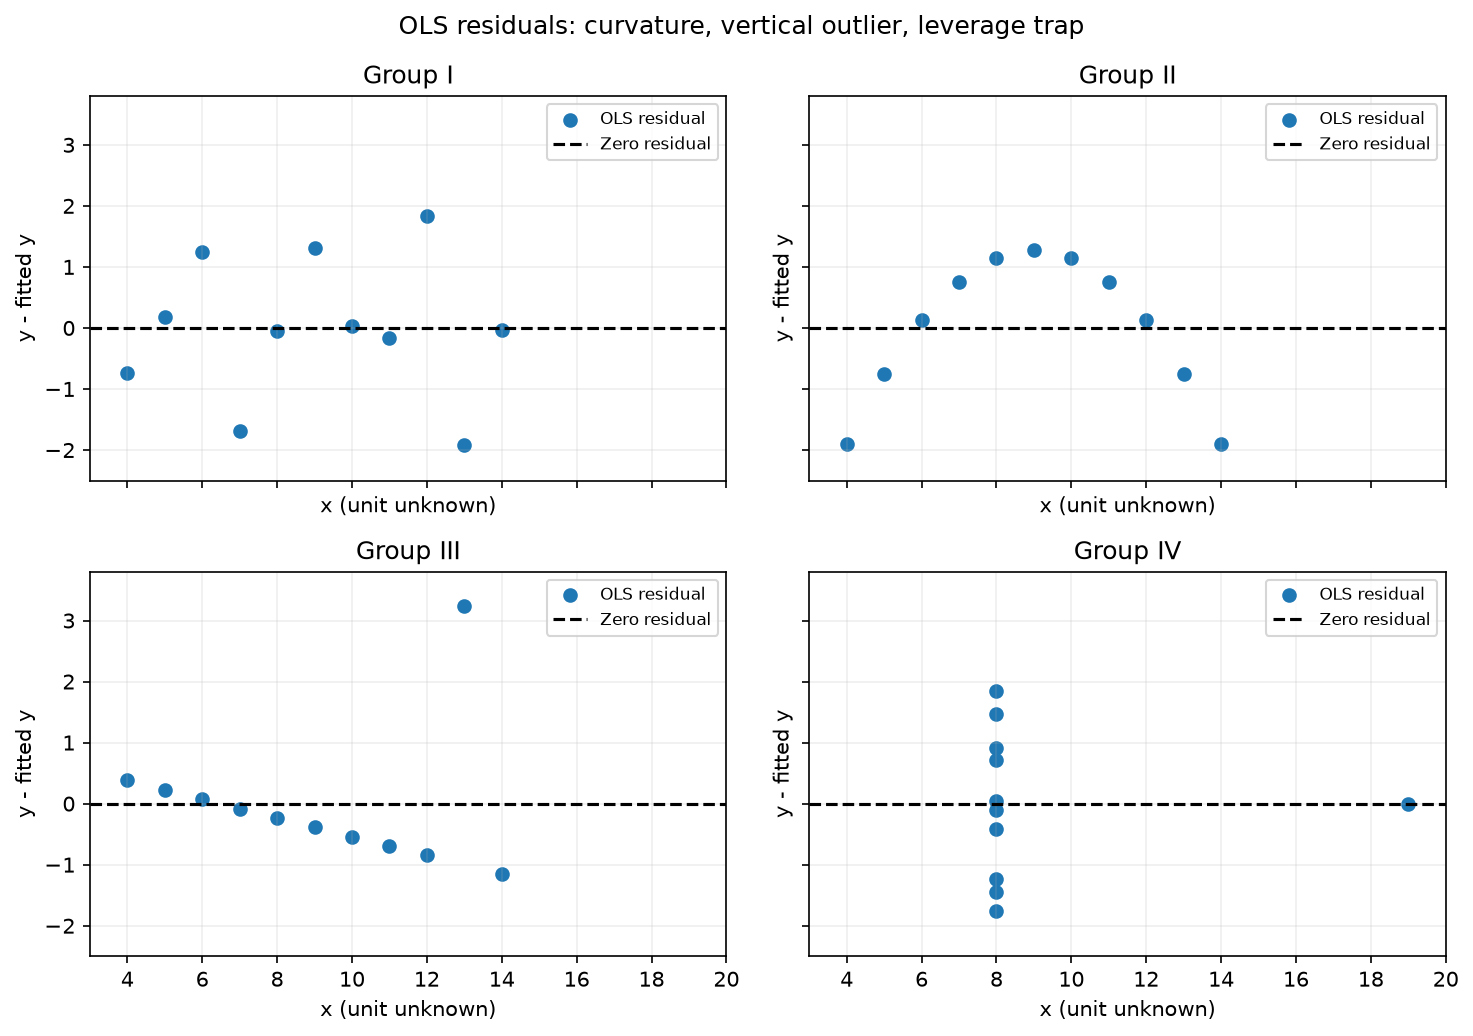

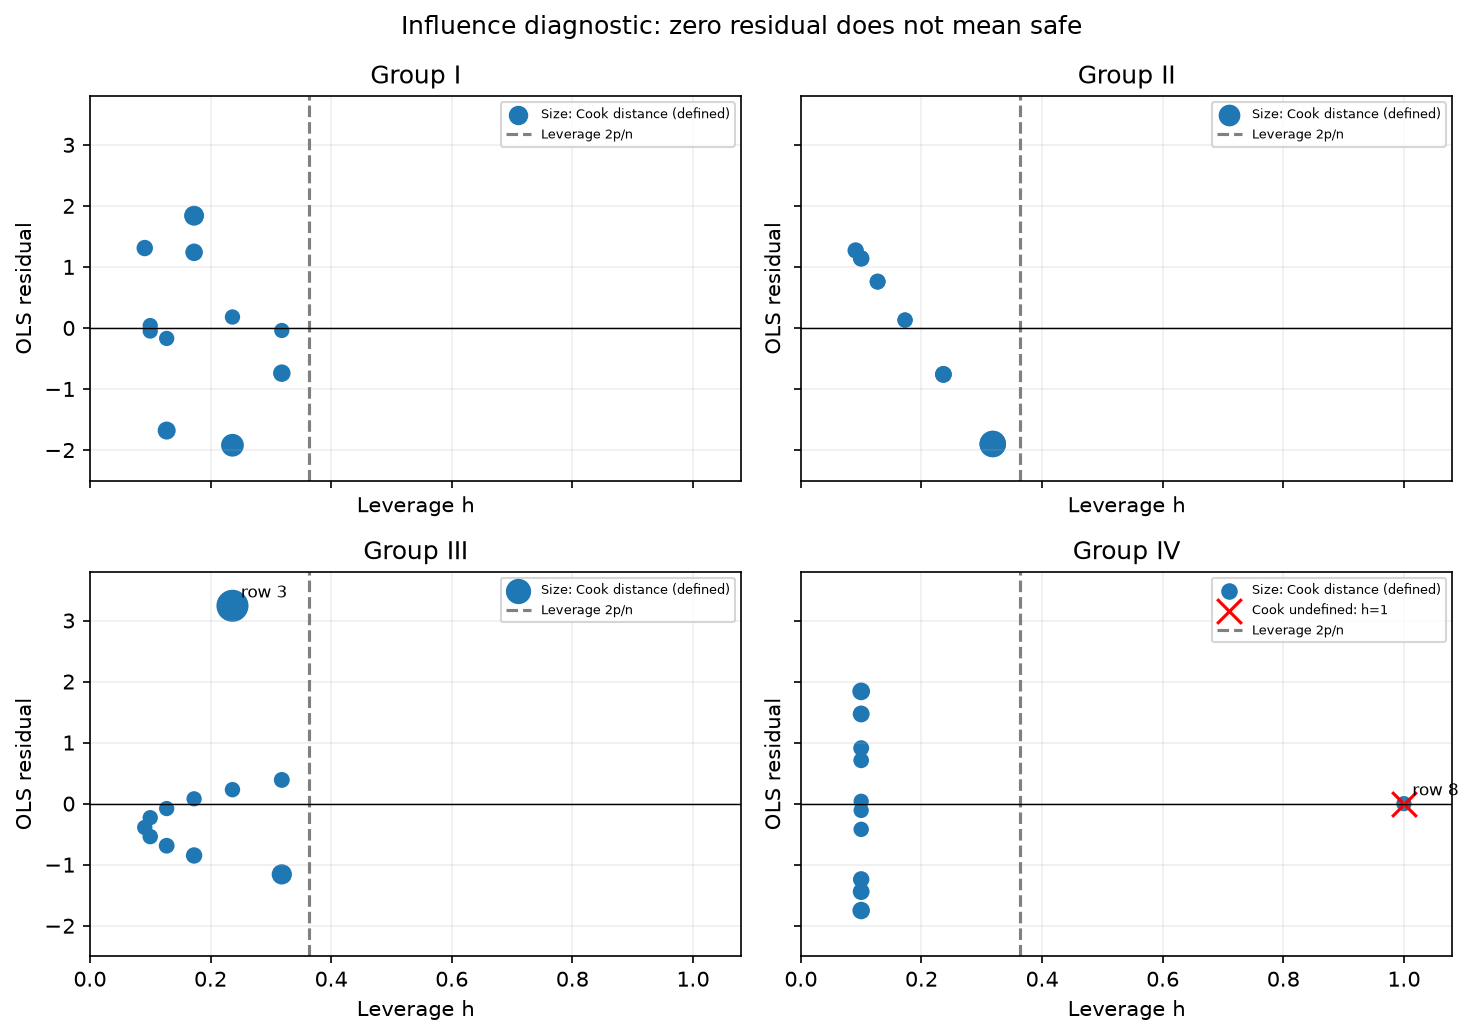

In [7]:
# 共通軸の散布図、残差図、レバレッジと残差。図のPNGをNotebookに保存。
import matplotlib.pyplot as plt
import warnings
from ai_data_scientist import visualization
chart_specs = {}
with phase('visualization'):
    def show_png(fig, name, title, xlabel, ylabel, legend):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            buffer = io.BytesIO()
            fig.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
        plt.close(fig)
        glyph_warnings = [str(w.message) for w in caught if 'Glyph' in str(w.message)]
        if glyph_warnings:
            raise RuntimeError('図のグリフ欠落: ' + '; '.join(glyph_warnings))
        png = buffer.getvalue()
        output = visualization.build_image_output(png)
        display(output['data'], raw=True)
        chart_specs[name] = {'title': title, 'xlabel': xlabel, 'ylabel': ylabel,
                             'legend': legend, 'missing_glyphs': [], 'bytes': len(png)}
    grid = np.linspace(3, 20, 300)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    for ax, group in zip(axes.flat, GROUPS):
        g = df[df.group == group]
        ax.scatter(g.x, g.y, label='Observed', color='#2166ac')
        ax.plot(grid, fits[group]['beta'][0] + fits[group]['beta'][1] * grid, label='OLS linear', color='#b2182b')
        if group == 'II':
            quad = fit_polynomial(g, 2)['beta']
            in_grid = np.linspace(g.x.min(), g.x.max(), 200)
            ax.plot(in_grid, np.polynomial.polynomial.polyval(in_grid, quad), label='Quadratic', color='#1b7837')
        for _, point in g.iterrows():
            if (group == 'III' and point.row_id == 3) or (group == 'IV' and point.row_id == 8):
                ax.annotate('row ' + str(point.row_id), (point.x, point.y), xytext=(4, 4), textcoords='offset points', fontsize=8)
        ax.set(title=f'Group {group}', xlabel='x (unit unknown)', ylabel='y (unit unknown)', xlim=(3, 20), ylim=(2, 14))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)
    fig.suptitle('Anscombe quartet: same summary, different geometry')
    fig.tight_layout()
    show_png(fig, 'scatter', 'Anscombe quartet: same summary, different geometry', 'x (unit unknown)', 'y (unit unknown)', ['Observed', 'OLS linear', 'Quadratic (II)'])
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    for ax, group in zip(axes.flat, GROUPS):
        d = diagnostics[diagnostics.group == group]
        ax.scatter(d.x, d.residual, label='OLS residual')
        ax.axhline(0, color='black', linestyle='--', label='Zero residual')
        ax.set(title=f'Group {group}', xlabel='x (unit unknown)', ylabel='y - fitted y', xlim=(3, 20), ylim=(-2.5, 3.8))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)
    fig.suptitle('OLS residuals: curvature, vertical outlier, leverage trap')
    fig.tight_layout()
    show_png(fig, 'residual', 'OLS residuals', 'x (unit unknown)', 'y - fitted y', ['OLS residual', 'Zero residual'])
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    for ax, group in zip(axes.flat, GROUPS):
        d = diagnostics[diagnostics.group == group]
        sizes = 40 + 120 * d.cook_distance.fillna(0).clip(0, 2)
        ax.scatter(d.leverage, d.residual, s=sizes, label='Size: Cook distance (defined)')
        invalid = d[~d.cook_defined]
        if len(invalid):
            ax.scatter(invalid.leverage, invalid.residual, marker='x', s=140, color='red', label='Cook undefined: h=1')
        ax.axvline(4 / 11, color='grey', linestyle='--', label='Leverage 2p/n')
        ax.axhline(0, color='black', linewidth=0.7)
        for _, point in d.iterrows():
            if (group == 'III' and point.row_id == 3) or (group == 'IV' and point.row_id == 8):
                ax.annotate('row ' + str(point.row_id), (point.leverage, point.residual), xytext=(4, 4), textcoords='offset points', fontsize=8)
        ax.set(title=f'Group {group}', xlabel='Leverage h', ylabel='OLS residual', xlim=(0, 1.08), ylim=(-2.5, 3.8))
        ax.legend(fontsize=6)
        ax.grid(alpha=0.2)
    fig.suptitle('Influence diagnostic: zero residual does not mean safe')
    fig.tight_layout()
    show_png(fig, 'influence', 'Influence diagnostic', 'Leverage h', 'OLS residual', ['Size: Cook distance', 'h=1 undefined', 'Leverage 2p/n'])
    print('chart metadata:', json.dumps(chart_specs))

In [8]:
# 感度分析: 全点対全1点除去、モデル次数、影響点閾値。
from ai_data_scientist import sensitivity
with phase('initial-sensitivity'):
    sensitivity_reports, deletion_rows = {}, []
    for group in GROUPS:
        g = df[df.group == group]
        valid_drops = [0]
        for row_id in g.row_id:
            subset = g[g.row_id != row_id]
            identifiable = fit_polynomial(subset)['identifiable']
            deletion_rows.append({'group': group, 'removed_row_id': int(row_id),
                                  'identifiable': identifiable,
                                  'slope': fit_polynomial(subset)['beta'][1] if identifiable else np.nan,
                                  'pearson_r': stats.pearsonr(subset.x, subset.y).statistic if identifiable else np.nan})
            if identifiable:
                valid_drops.append(int(row_id))
        plan = sensitivity.SensitivityPlan(parameter_grid={'removed_row_id': valid_drops}, max_runs=12)
        def slope_under_deletion(removed_row_id):
            subset = g if removed_row_id == 0 else g[g.row_id != removed_row_id]
            return float(fit_polynomial(subset)['beta'][1])
        report = sensitivity.run_sensitivity(plan, slope_under_deletion, stability_tolerance=0.2)
        sensitivity_reports[group] = report
    deletion_results = pd.DataFrame(deletion_rows)
    deletion_summary = deletion_results.groupby('group').agg(
        min_slope=('slope', 'min'), max_slope=('slope', 'max'),
        min_r=('pearson_r', 'min'), max_r=('pearson_r', 'max'), invalid=('identifiable', lambda x: int((~x).sum())))
    display(deletion_summary)
    display(deletion_results[(deletion_results.group == 'III') & (deletion_results.removed_row_id == 3)])
    slope_stability = {g: {'stable': r.stable, 'max_relative_deviation': r.max_relative_deviation,
                           'valid_specs': len(r.results), 'invalid_specs': int(deletion_summary.loc[g, 'invalid'])}
                       for g, r in sensitivity_reports.items()}
    model_sensitivity = {}
    for group in GROUPS[:3]:
        plan = sensitivity.SensitivityPlan({'degree': [1, 2]}, max_runs=2)
        report = sensitivity.run_sensitivity(plan, lambda degree: float(models[(models.group == group) & (models.degree == degree)].loocv_rmse.iloc[0]), stability_tolerance=0.2)
        model_sensitivity[group] = asdict(report)
    threshold_plan = sensitivity.SensitivityPlan({'threshold': [4 / 11, 1.0]}, max_runs=2)
    threshold_report = sensitivity.run_sensitivity(threshold_plan,
        lambda threshold: float((diagnostics[diagnostics.group == 'III'].cook_distance > threshold).sum()),
        stability_tolerance=0.0)
    sensitivity_evidence = {'slope_stability': slope_stability, 'model_sensitivity': model_sensitivity,
                            'III_cook_threshold': asdict(threshold_report),
                            'III_drop3_slope': float(deletion_results[(deletion_results.group == 'III') & (deletion_results.removed_row_id == 3)].slope.iloc[0]),
                            'IV_drop8_unidentifiable': bool(not deletion_results[(deletion_results.group == 'IV') & (deletion_results.removed_row_id == 8)].identifiable.iloc[0])}
    display({'text/plain': json.dumps(sensitivity_evidence, ensure_ascii=False)}, raw=True)
    print('注意: IVのstable=Trueは識別可能な11仕様に限る。第8点除去で傾き・相関が未定義となるため、全仕様では頑健と結論しない。')

注意: IVのstable=Trueは識別可能な11仕様に限る。第8点除去で傾き・相関が未定義となるため、全仕様では頑健と結論しない。


,min_slope,max_slope,min_r,max_r,invalid
group,,,,,
I,0.439471,0.591580,0.750974,0.885226,0
II,0.373273,0.626727,0.758661,0.890312,0
III,0.345390,0.576970,0.792111,0.999997,0
IV,0.482222,0.518485,0.814672,0.863525,1


,group,removed_row_id,identifiable,slope,pearson_r
24,III,3,True,0.34539,0.999997


{"slope_stability": {"I": {"stable": true, "max_relative_deviation": 0.1829450922343124, "valid_specs": 12, "invalid_specs": 0}, "II": {"stable": false, "max_relative_deviation": 0.2534545454545457, "valid_specs": 12, "invalid_specs": 0}, "III": {"stable": false, "max_relative_deviation": 0.30884378492164627, "valid_specs": 12, "invalid_specs": 0}, "IV": {"stable": true, "max_relative_deviation": 0.03715827120082372, "valid_specs": 11, "invalid_specs": 1}}, "model_sensitivity": {"I": {"results": [{"specification": {"degree": 1}, "value": 1.367787020518828}, {"specification": {"degree": 2}, "value": 1.3981168400113562}], "baseline_value": 1.367787020518828, "stable": true, "max_relative_deviation": 0.022174372937844827}, "II": {"results": [{"specification": {"degree": 1}, "value": 1.4846484554673898}, {"specification": {"degree": 2}, "value": 0.0017639745110523619}], "baseline_value": 1.4846484554673898, "stable": false, "max_relative_deviation": 0.9988118571069425}, "III": {"results": 

In [9]:
# 初回解釈と反復依頼履歴を根拠付きで保存する。
from ai_data_scientist import insight_engine
request1 = '丸め誤差や推定法の選択によって、群IIの曲線性と群IIIの単一点への依存という解釈が変わるか確認してください。yを記録精度に相当する±0.005の範囲で変動させ、OLSとTheil–Senを比較し、群IVで頑健推定を使っても識別問題が解決しない理由を説明してください。'
request2 = '群IIの正の相関を「xが増えるほど常にyが増える」と誤読できないよう、観測範囲内の二次曲線の頂点と局所傾き、隣接点の変化を比較してください。群IVについてはxの支持範囲と未観測区間を明示し、同じ回帰直線を同じ予測根拠として使えるか検証してください。'
def record_claim(tag, text, marker, pattern):
    if text.startswith('# '):
        title, body = text.split('\n', 1)
        text = '**' + title[2:] + '**\n' + body
    nb = nbformat.read(handle.notebook_path, as_version=4)
    matches = [c for c in nb.cells if c.cell_type == 'code' and c.source.startswith(marker)]
    if len(matches) != 1:
        raise RuntimeError('根拠セルの一意性違反: ' + marker)
    cell = matches[0]
    output_text = '\n'.join(str(o.get('data', {}).get('text/plain', '')) for o in cell.get('outputs', []))
    value = insight_engine.extract_cited_value({'output': output_text}, pattern)
    def remove_old(nb):
        nb.cells = [c for c in nb.cells if c.metadata.get('report_tag') != tag]
    write_notebook(remove_old)
    with phase('insight-write', writing=True):
        insight_engine.record_insight(handle, text, cell.execution_count, value, claim_type='associational', language='ja')
    write_notebook(lambda nb: nb.cells[-1].metadata.update({'report_tag': tag}))
with phase('initial-review'):
    record_claim('initial-insight', '# 初回分析の結果と解釈\n4群のx平均9、標本分散11、y平均約7.50、y標本分散約4.12、Pearson r約0.816、直線y≈3+0.5xはほぼ共通だが、同じ構造ではない。Iは散らばりを伴う線形傾向、IIは残差に曲率が現れ二次モデルのLOOCV RMSEが約1.485から約0.001764へ改善、IIIは第3点の影響、IVはx=19の第8点だけが傾きの識別を可能にしている。IVのh=1ではCook距離が未定義であり、残差ゼロを安全性の証拠にしてはいけない。相関モジュールの「強い正の相関」は係数の記述に限り、線形性・因果・予測頑健性の保証ではない。', '# 要約統計・OLS', r'"max_cook_III": ([0-9.eE+-]+)')
    add_markdown('iteration-history', '# 反復依頼履歴\n\n## 反復1: 原文\n' + request1 + '\n\n選定理由: 初回の強い曲線性と影響点依存が、2桁記録の丸めやOLSの選択だけで生じたものか未確認。結論への影響があるため検査する。\n\n## 反復2: 原文\n' + request2 + '\n\n選定理由: 正相関を全域の単調増加や共通の予測根拠と取り違える危険が残る。観測範囲内の局所方向と支持範囲を確認する。\n\n最大3回まで。実行結果を読んだ後に停止理由と残る限界を追記する。')
    receipt = '初回解釈と追加依頼2件を保存。原文は履歴に記録。'
    display({'text/plain': receipt}, raw=True)
    current_count = len(get_ipython().history_manager.input_hist_raw) - 1
    def persist_receipt(nb):
        cell = next(c for c in nb.cells if c.cell_type == 'code' and c.source.startswith('# 初回解釈と反復依頼履歴'))
        cell.execution_count = current_count
        cell.outputs = [nbformat.v4.new_output('display_data', data={'text/plain': receipt})]
    write_notebook(persist_receipt)

初回解釈と追加依頼2件を保存。原文は履歴に記録。

# 反復依頼履歴

## 反復1: 原文
丸め誤差や推定法の選択によって、群IIの曲線性と群IIIの単一点への依存という解釈が変わるか確認してください。yを記録精度に相当する±0.005の範囲で変動させ、OLSとTheil–Senを比較し、群IVで頑健推定を使っても識別問題が解決しない理由を説明してください。

選定理由: 丸めとOLS選択への依存が未確認。結果: 曲線性とIIIの影響点依存は丸め100仕様でも残り、Theil–SenでもIIIの解釈を支持。証拠: 反復1コードのiteration1_evidenceおよび隣接Insight。限界: シナリオ検査であって誤差分布・母集団の推定ではない。

## 反復2: 原文
群IIの正の相関を「xが増えるほど常にyが増える」と誤読できないよう、観測範囲内の二次曲線の頂点と局所傾き、隣接点の変化を比較してください。群IVについてはxの支持範囲と未観測区間を明示し、同じ回帰直線を同じ予測根拠として使えるか検証してください。

選定理由: 正相関を常時増加・同じ予測根拠と誤読する余地。結果: IIの頂点と下降区間、IVの2水準のみのxと大きい空白を確認。証拠: 反復2コードのiteration2_evidence、支持範囲表、補助図。限界: IIIの観測の真偽、IVの未観測区間、外部妥当性は追加データなしに確定不能。

停止理由: 2回で結論に実質的に影響する未解決点を解消。残る限界は追加観測を要し、同じ教材内の第3回には価値がない。

In [10]:
# 反復1: 原文依頼は「反復依頼履歴」。丸め幅と推定法の感度を検査。
with phase('iteration-1'):
    robust_rows = []
    for group in GROUPS:
        g = df[df.group == group]
        robust = stats.theilslopes(g.y, g.x)
        robust_rows.append({'group': group, 'OLS_slope': fits[group]['beta'][1],
                            'Theil_Sen_slope': robust.slope, 'distinct_x': g.x.nunique(),
                            'note': 'x=19の1点との対だけから傾きが作られる。削除すれば未定義' if group == 'IV' else '全点で算出'})
    robust_comparison = pd.DataFrame(robust_rows)
    display(robust_comparison)
    def loocv_error(g, degree):
        errors = []
        for position in range(len(g)):
            test = g.iloc[position]
            fit = fit_polynomial(g.drop(g.index[position]), degree)
            if not fit['identifiable']:
                raise ValueError('LOOCVの傾きが識別不能')
            prediction = np.array([test.x ** d for d in range(degree + 1)]) @ fit['beta']
            errors.append((test.y - prediction) ** 2)
        return float(np.sqrt(np.mean(errors)))
    rounding_rows = []
    def rounding_analysis(amplitude, seed):
        rng = np.random.default_rng(seed)
        g2 = df[df.group == 'II'].copy()
        g3 = df[df.group == 'III'].copy()
        g2['y'] = g2.y + rng.uniform(-amplitude, amplitude, len(g2))
        g3['y'] = g3.y + rng.uniform(-amplitude, amplitude, len(g3))
        linear_cv, quadratic_cv = loocv_error(g2, 1), loocv_error(g2, 2)
        full = fit_polynomial(g3)['beta'][1]
        removed = fit_polynomial(g3[g3.row_id != 3])['beta'][1]
        gain = 1 - quadratic_cv / linear_cv
        rounding_rows.append({'amplitude': amplitude, 'seed': seed, 'II_cv_improvement_fraction': gain,
                              'III_drop3_relative_slope_change': abs(removed - full) / abs(full)})
        return float(gain)
    rounding_plan = sensitivity.SensitivityPlan({'amplitude': [0.0, 0.005], 'seed': list(range(12, 62))}, max_runs=100)
    rounding_report = sensitivity.run_sensitivity(rounding_plan, rounding_analysis, stability_tolerance=0.01)
    rounding_results = pd.DataFrame(rounding_rows)
    display(rounding_results.groupby('amplitude').agg(
        II_gain_min=('II_cv_improvement_fraction', 'min'), II_gain_max=('II_cv_improvement_fraction', 'max'),
        III_change_min=('III_drop3_relative_slope_change', 'min'), III_change_max=('III_drop3_relative_slope_change', 'max')))
    iteration1_evidence = {'rounding_runs': len(rounding_report.results), 'rounding_stable': rounding_report.stable,
                           'rounding_max_relative_deviation': rounding_report.max_relative_deviation,
                           'II_min_cv_gain': rounding_results.II_cv_improvement_fraction.min(),
                           'III_min_drop3_relative_change': rounding_results.III_drop3_relative_slope_change.min(),
                           'III_Theil_Sen_slope': robust_comparison[robust_comparison.group == 'III'].Theil_Sen_slope.iloc[0],
                           'IV_Theil_Sen_slope': robust_comparison[robust_comparison.group == 'IV'].Theil_Sen_slope.iloc[0]}
    assert iteration1_evidence['II_min_cv_gain'] > 0.99
    assert iteration1_evidence['III_min_drop3_relative_change'] > 0.30
    display({'text/plain': json.dumps(iteration1_evidence, ensure_ascii=False)}, raw=True)
    print('限界: ±0.005は記録桁から設定したシナリオで、真の測定誤差や母集団の分布ではない。Theil–Sen区間を母集団推論として利用しない。')

限界: ±0.005は記録桁から設定したシナリオで、真の測定誤差や母集団の分布ではない。Theil–Sen区間を母集団推論として利用しない。


,group,OLS_slope,Theil_Sen_slope,distinct_x,note
0,I,0.500091,0.501667,11,全点で算出
1,II,0.500000,0.500000,11,全点で算出
2,III,0.499727,0.345556,11,全点で算出
3,IV,0.499909,0.503182,2,x=19の1点との対だけから傾きが作られる。削除すれば未定義


,II_gain_min,II_gain_max,III_change_min,III_change_max
amplitude,,,,
0.000,0.998812,0.998812,0.308844,0.308844
0.005,0.996369,0.998499,0.307908,0.309573


{"rounding_runs": 100, "rounding_stable": true, "rounding_max_relative_deviation": 0.00244574608229291, "II_min_cv_gain": 0.9963690169204755, "III_min_drop3_relative_change": 0.30790849074594023, "III_Theil_Sen_slope": 0.3455555555555555, "IV_Theil_Sen_slope": 0.5031818181818182}

反復停止判断: 2回で主要未解決点は解消。IIIの点を誤記と断定せず、IVの未観測区間は追加データなしには識別できない。第3回は外部妥当性の保証を増やせないため実施しない。


,row_id,x,y,delta_y_next,quadratic_derivative
18,8,4.0,3.10,1.64,1.767133
21,11,5.0,4.74,1.39,1.513706
17,7,6.0,6.13,1.13,1.260280
20,10,7.0,7.26,0.88,1.006853
12,2,8.0,8.14,0.63,0.753427
14,4,9.0,8.77,0.37,0.500000
11,1,10.0,9.14,0.12,0.246573
15,5,11.0,9.26,-0.13,-0.006853
19,9,12.0,9.13,-0.39,-0.260280
13,3,13.0,8.74,-0.64,-0.513706


,group,n_unique_x,x_min,x_max,largest_observed_gap
0,I,11,4.0,14.0,1.0
1,II,11,4.0,14.0,1.0
2,III,11,4.0,14.0,1.0
3,IV,2,8.0,19.0,11.0


{"II_vertex_x": 10.972958057395058, "II_derivative_x14": -0.767132867132895, "II_observed_y11_minus_y14": 1.1600000000000001, "IV_points_x8": 10, "IV_points_x19": 1, "IV_largest_x_gap": 11.0}

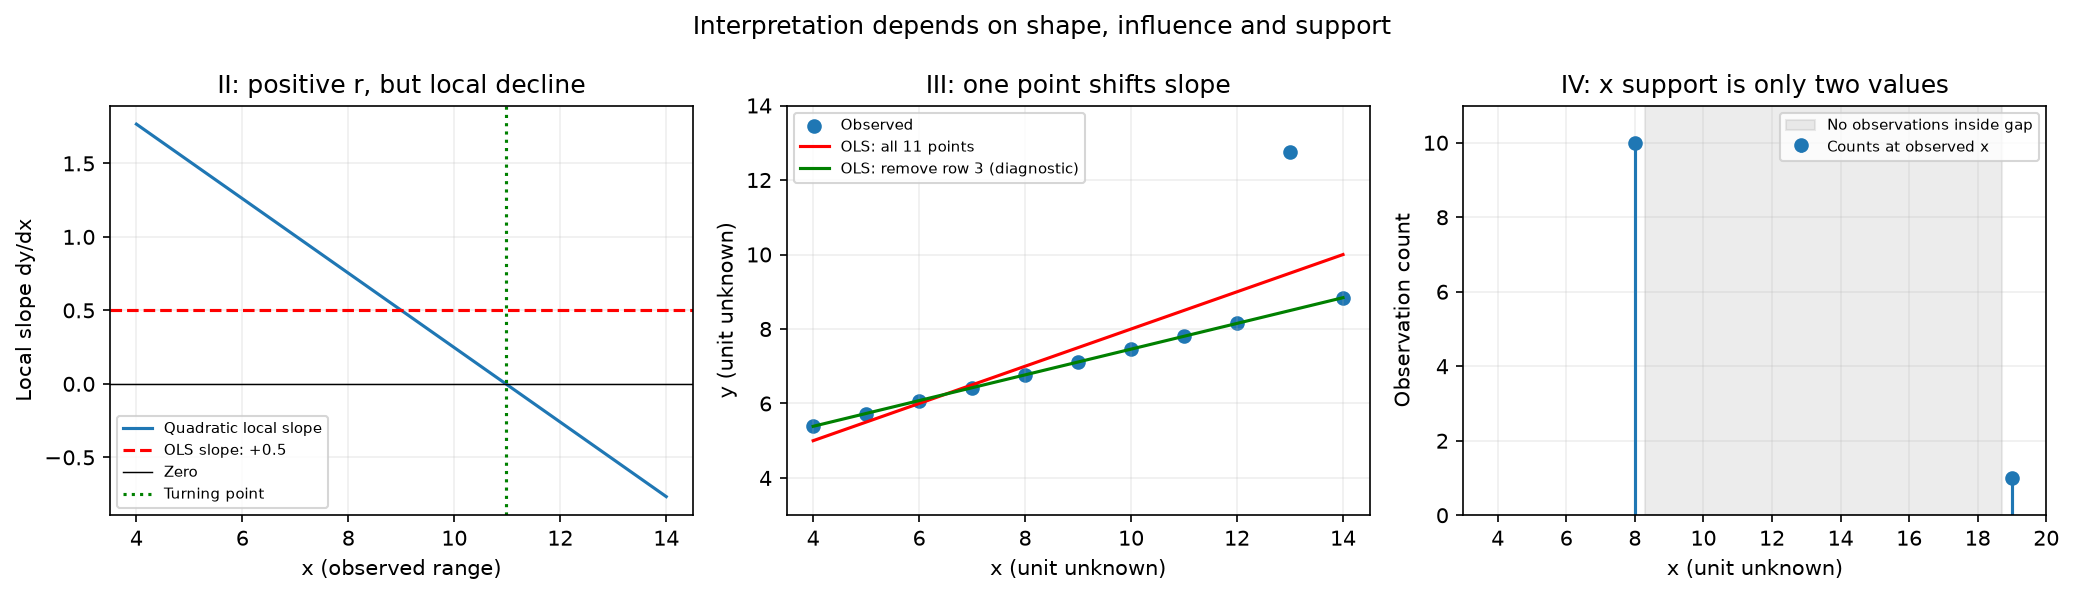

In [11]:
# 反復2: 局所方向・観測支持範囲・予測根拠を比較。
with phase('iteration-2'):
    g2 = df[df.group == 'II'].sort_values('x')
    q = fit_polynomial(g2, 2)['beta']
    vertex = -q[1] / (2 * q[2])
    neighbor_changes = g2[['row_id', 'x', 'y']].copy()
    neighbor_changes['delta_y_next'] = neighbor_changes.y.shift(-1) - neighbor_changes.y
    neighbor_changes['quadratic_derivative'] = q[1] + 2 * q[2] * neighbor_changes.x
    support = df.groupby(['group', 'x']).size().rename('count').reset_index()
    support_rows = []
    for group in GROUPS:
        xs = np.sort(df[df.group == group].x.unique())
        support_rows.append({'group': group, 'n_unique_x': len(xs), 'x_min': xs.min(), 'x_max': xs.max(),
                             'largest_observed_gap': float(np.diff(xs).max())})
    support_summary = pd.DataFrame(support_rows)
    display(neighbor_changes)
    display(support_summary)
    g3 = df[df.group == 'III']
    fit3_without = fit_polynomial(g3[g3.row_id != 3])
    iteration2_evidence = {'II_vertex_x': float(vertex), 'II_derivative_x14': float(q[1] + 28 * q[2]),
                           'II_observed_y11_minus_y14': float(g2[g2.x == 11].y.iloc[0] - g2[g2.x == 14].y.iloc[0]),
                           'IV_points_x8': int((df[df.group == 'IV'].x == 8).sum()),
                           'IV_points_x19': int((df[df.group == 'IV'].x == 19).sum()),
                           'IV_largest_x_gap': float(support_summary[support_summary.group == 'IV'].largest_observed_gap.iloc[0])}
    display({'text/plain': json.dumps(iteration2_evidence, ensure_ascii=False)}, raw=True)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    local_grid = np.linspace(4, 14, 200)
    axes[0].plot(local_grid, q[1] + 2 * q[2] * local_grid, label='Quadratic local slope')
    axes[0].axhline(fits['II']['beta'][1], color='red', linestyle='--', label='OLS slope: +0.5')
    axes[0].axhline(0, color='black', linewidth=0.7, label='Zero')
    axes[0].axvline(vertex, color='green', linestyle=':', label='Turning point')
    axes[0].set(title='II: positive r, but local decline', xlabel='x (observed range)', ylabel='Local slope dy/dx')
    axes[1].scatter(g3.x, g3.y, label='Observed')
    axes[1].plot(local_grid, np.polynomial.polynomial.polyval(local_grid, fits['III']['beta']), label='OLS: all 11 points', color='red')
    axes[1].plot(local_grid, np.polynomial.polynomial.polyval(local_grid, fit3_without['beta']), label='OLS: remove row 3 (diagnostic)', color='green')
    axes[1].set(title='III: one point shifts slope', xlabel='x (unit unknown)', ylabel='y (unit unknown)', ylim=(3, 14))
    axes[2].stem([8, 19], [10, 1], basefmt=' ', label='Counts at observed x')
    axes[2].axvspan(8.3, 18.7, color='grey', alpha=0.15, label='No observations inside gap')
    axes[2].set(title='IV: x support is only two values', xlabel='x (unit unknown)', ylabel='Observation count', xlim=(3, 20), ylim=(0, 11))
    for ax in axes:
        ax.legend(fontsize=7)
        ax.grid(alpha=0.2)
    fig.suptitle('Interpretation depends on shape, influence and support')
    fig.tight_layout()
    show_png(fig, 'iteration2', 'Interpretation depends on shape, influence and support', 'x (observed range / unknown unit)', 'Local slope / y / count', ['Local vs OLS slope', 'All vs leave-one-out', 'Observed support and gap'])
    print('反復停止判断: 2回で主要未解決点は解消。IIIの点を誤記と断定せず、IVの未観測区間は追加データなしには識別できない。第3回は外部妥当性の保証を増やせないため実施しない。')

In [12]:
# Jupytermind改善候補の最小再現（本分析の結果と分離）。
with phase('module-applicability-check'):
    nan_plan = sensitivity.SensitivityPlan({'case': ['finite', 'undefined']}, max_runs=2)
    nan_report = sensitivity.run_sensitivity(nan_plan, lambda case: 1.0 if case == 'finite' else float('nan'))
    inferred_manifest = data_definition.build_manifest(source={}, dataset_scope={},
        variables={'x': {'definition': FieldValue('推定された説明変数', 'inferred', '列名')}})
    improvement_evidence = {'nan_input_report_stable': nan_report.stable,
                            'nan_input_max_relative_deviation': nan_report.max_relative_deviation,
                            'nan_input_values': [r.value for r in nan_report.results],
                            'inferred_only_unresolved_fields_count': len(inferred_manifest.unresolved_fields())}
    display({'text/plain': json.dumps(improvement_evidence, ensure_ascii=False)}, raw=True)
    print('切り分け: Kaggle認証/検索/取得は成功。NaNとinferredの再現はKaggle API・CLI・ベンチマークランナーを使わず、Jupytermind関数のみを直接呼び出している。')

切り分け: Kaggle認証/検索/取得は成功。NaNとinferredの再現はKaggle API・CLI・ベンチマークランナーを使わず、Jupytermind関数のみを直接呼び出している。


{"nan_input_report_stable": true, "nan_input_max_relative_deviation": 0.0, "nan_input_values": [1.0, NaN], "inferred_only_unresolved_fields_count": 0}

In [13]:
# 最終保存・根拠更新・再現性比較・notebook_audit・ライフサイクル終了。
from ai_data_scientist import notebook_audit
artifacts_dir = handle.root / 'artifacts'
artifacts_dir.mkdir(exist_ok=True)
def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, (float, np.floating)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.bool_):
        return bool(value)
    return value
def save_json(name, payload):
    with phase('artifact-write:' + name, writing=True):
        (artifacts_dir / name).write_text(json.dumps(json_safe(payload), ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
with phase('final-report'):
    assumptions_final = AnalysisAssumptionManifest(
        analysis_scope={'population': '固定教材4群のみ', 'variance_ddof': 1, 'slope_stability_tolerance': 0.2,
                        'rounding_amplitude': 0.005, 'rounding_seeds': list(range(12, 62))}, causal_scope='associational',
        assumptions=(Assumption('mapping', '各群11点・列対応・有限値・欠損なしを確認', 'tested', conclusion_critical=True),
                     Assumption('models', '単一線形モデルの妥当性は群別に比較し、全4群で共通とは仮定しない', 'tested', conclusion_critical=True),
                     Assumption('rank', '定数xを傾きゼロではなく識別不能と扱う', 'tested', conclusion_critical=True),
                     Assumption('precision', '±0.005は丸め幅に基づく有限シナリオで真の誤差分布ではない', 'assumed'),
                     Assumption('sampling', '教材を実測母集団のiid標本や因果効果として一般化しない', 'verified')))
    final_assumption_findings = analysis_assumptions.check_manifest(assumptions_final)
    assert not final_assumption_findings
    record_claim('sensitivity-insight', '# 感度分析の結果\n全点対各1点除去で、傾きの最大相対変化はI=18.29%、II=25.35%、III=30.88%。20%閾値のstable判定はI=True、II/III=False。IVは識別可能な仕様だけならTrue・3.72%だが、第8点除去が識別不能なので全仕様の頑健性は否定される。20%は便宜的な判定幅で同等性の統計検定ではない。IIIの第3点はCook距離4/n・1の両閾値で影響点となる。削除は診断であり、誤記や不要な観測と断定していない。', '# 感度分析:', r'"III_drop3_slope": ([0-9.eE+-]+)')
    record_claim('iteration1-insight', '# 反復1の結果・証拠・限界\n100仕様（丸め幅0/0.005、seed12〜61）で、群IIの二次モデルのLOOCV RMSE改善率は最低99.6369%、群IIIの第3点除去による傾き変化は最低30.7908%。改善率の安定性はstable=True、max_relative_deviation≈0.002446（許容1%）。IIIのTheil–Sen傾き≈0.345556は除去時OLS≈0.345390と整合し、全点OLS≈0.499727とは異なる。一方、IVのTheil–Senもx=19の同じ1点を使う対に依存し、頑健推定だけでは支持範囲不足を解消しない。丸めシナリオは実測誤差の推定ではなく、100仕様は全ての摂動を網羅する保証でもない。', '# 反復1:', r'"II_min_cv_gain": ([0-9.eE+-]+)')
    record_claim('iteration2-insight', '# 反復2の結果・証拠・限界\n群IIの二次曲線はx≈10.973で最大となり、x=14で局所傾き≈−0.767。実際の観測値もx=11の9.26からx=14の8.10へ低下する。正のPearson相関を全域の単調増加と解釈してはいけない。群IVはx=8に10点、x=19に1点だけで、その間の11幅の区間に観測がない。同じ直線式でも補間を支える点の配置は異なる。新規xでの関係を保証するには追加観測が必要。反復2で主要未解決点を解消し、3回目は追加データなしに外部妥当性を改善できないので停止。', '# 反復2:', r'"II_vertex_x": ([0-9.eE+-]+)')
    record_claim('final-conclusion', '# 結論: 要約統計が似ていても同じ結論として扱わない\n同じと言えるのは指定した平均・標本分散・Pearson相関・OLS係数という要約値の近似的一致だけである。群Iは観測範囲の線形近似が比較的妥当、群IIは曲線性、群IIIは縦方向の影響点、群IVは高レバレッジ点とx支持範囲の欠如が本質的に異なる。散布図の共通軸比較、残差対x、影響度と1点除去、線形/二次のLOOCV、xの観測頻度・空白区間を合わせて比較すべきで、平均・分散・相関やヒストグラムだけでは共同構造を評価できない。小標本・固定教材なので「群Iが正しい母集団モデル」や因果・実世界への一般化は主張しない。', '# 要約統計・OLS', r'"pearson_r": ([0-9.eE+-]+)')
    add_markdown('iteration-history', '# 反復依頼履歴\n\n## 反復1: 原文\n' + request1 + '\n\n選定理由: 丸めとOLS選択への依存が未確認。結果: 曲線性とIIIの影響点依存は丸め100仕様でも残り、Theil–SenでもIIIの解釈を支持。証拠: 反復1コードのiteration1_evidenceおよび隣接Insight。限界: シナリオ検査であって誤差分布・母集団の推定ではない。\n\n## 反復2: 原文\n' + request2 + '\n\n選定理由: 正相関を常時増加・同じ予測根拠と誤読する余地。結果: IIの頂点と下降区間、IVの2水準のみのxと大きい空白を確認。証拠: 反復2コードのiteration2_evidence、支持範囲表、補助図。限界: IIIの観測の真偽、IVの未観測区間、外部妥当性は追加データなしに確定不能。\n\n停止理由: 2回で結論に実質的に影響する未解決点を解消。残る限界は追加観測を要し、同じ教材内の第3回には価値がない。')
    definitions_payload = asdict(definitions)
    unresolved_caveats = [(f'{section}.{key}', value) for section in ['source', 'dataset_scope'] for key, value in definitions_payload[section].items() if isinstance(value, dict) and value.get('status') in ['unknown', 'inferred']]
    unresolved_caveats += [(f'variables.{var}.{key}', value) for var, fields in definitions_payload['variables'].items() for key, value in fields.items() if value['status'] in ['unknown', 'inferred']]
    add_markdown('manifests', '# データ定義manifestと分析前提manifest\n```json\n' + json.dumps({'data_definition': definitions_payload, 'analysis_assumptions': asdict(assumptions_final), 'assumption_findings': [asdict(f) for f in final_assumption_findings], 'unknown_or_inferred_caveats': unresolved_caveats}, ensure_ascii=False, indent=2) + '\n```\n\n人口・測定機構・物理単位はunknown、教材の目的や説明/応答という役割はinferred。群や行番号・ファイル同一性は検証済みだが、意味的定義の確実性とは区別する。意味的異常なしは宣言したキー・欠損・群カテゴリ・行番号制約についてのみ。外れた点と繰り返すxを意味的異常とは断定しない。初回前提検査でlinear仮説がassumedという警告を検出したが、最終段階は群別モデル比較をtestedとして記録し、共通線形性を前提から除いた。')
    module_text = '''# 使用したJupytermindモジュール
直接import・呼出のみを記載。間接利用は数えない。

| モジュール | 直接呼んだ関数・クラス・メソッド | 目的 |
|---|---|---|
| ai_data_scientist.project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 保存先・データ配置・直列化されたNotebook書込み |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | run_idと実行/書込み/終了状態 |
| ai_data_scientist.language_router | detect_language | 日本語判定 |
| ai_data_scientist.ingestion | SourceSpec, ingest | Kaggle取得済みCSVの読込み |
| ai_data_scientist.cleaning | clean_dataset | 欠損除去の影響確認（44→44、削除0） |
| ai_data_scientist.eda | explore | 型・欠損・カテゴリ・基本統計 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 定義と確実性・出典の区別 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 前提と記述/関連の範囲 |
| ai_data_scientist.data_quality | detect_anomalies | 意味的スキーマ検査 |
| ai_data_scientist.stats_analysis | correlation | Pearson統計と日本語の係数解釈 |
| ai_data_scientist.visualization | build_image_output | 実行済み図をPNG MIMEとして保存 |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 1点除去・次数・閾値・丸めの有限感度検査 |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight | 保存済み出力から引用抽出、実行回数を結ぶ証拠manifest |
| ai_data_scientist.notebook_audit | audit_notebook | visual_audit=Trueの最終監査 |

mcp_gateway.run_and_record、visualization.render_chart/record_chart、dataset_validation.compare_datasets、data_quality.validate_anomaliesは直接使用していない。理由は計画の適用範囲を参照。複合図はMatplotlibで作成しPNGをbuild_image_outputへ渡した。API取得・分析・保存処理のコード実行は全てJupyter MCP。端末・subprocess・委譲なし。'''
    add_markdown('modules', module_text)
    record_claim('improvements', '# Jupytermind改善候補\n\n| 分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策 | 関係セル・ログ |\n|---|---|---|---|---|---|---|\n| sensitivity: 非有限値入力の不具合候補 | 2仕様で1.0とNaNを返す | 拒否、明示的な未評価/不安定状態 | stable=True、max_relative_deviation=0.0 | 未定義仕様を含むのに頑健性を誤認し得る | rank/有限値を呼出前に検査し、IVの無効仕様を別件数で明示。本分析ではNaNを感度判定に渡さない | 最小再現コード: nan_input_report_stable、nan_input_values |\n| data_definition: 確実性集約の機能不足候補（仕様どおりであり不具合とは断定しない） | inferredだけのmanifestでunresolved_fieldsを呼ぶ | optionalにunknownとinferred両方の注意点を集約 | unknownだけを返し、この再現では0件 | inferredが確認済みと誤読されるリスク | statusを別走査し両方をNotebookとmanifestに保存 | 最小再現コード: inferred_only_unresolved_fields_count、定義コード: inferred fields |\n\n両候補は外部接続不要の直接関数呼出で再現し、Kaggle API・CLI・ベンチマークランナー固有問題から分離した。ソースコードの修正やIssue登録はこの分析では行わない。\n\n統合上の別記録: 活性Notebookの実行セルからenqueue_writeで同Notebookを変更した初回に、MCPはCOMPLETEDを返す一方で出力やexecution_countが保持されない事象を観測した（初回報告セルはread_notebookでCount=N/A）。これはファイル書込みとJupyter MCPの実行結果保存の競合で、Jupytermind単体の故障と断定しない。期待: 自己書込みでも実行情報が保持される。影響: 未実行誤判定・根拠の欠落。回避: 自己書込みセルは実際のIPython入力履歴番号と生成した出力をenqueue_writeで明示保存し、別の監査で確認。execution_countを次番号から推測せず入力履歴の実番号を使用。ログ: 本Notebookの初回報告/最終保存セルのreceiptとartifacts/lifecycle-log.json。', '# Jupytermind改善候補の最小再現', r'"nan_input_report_stable": (true)')
    save_json('data-definition-manifest.json', definitions_payload)
    save_json('analysis-assumptions-manifest.json', asdict(assumptions_final))
    save_json('kaggle-provenance.json', {'acquisition': provenance, 'catalog': catalog, 'file_listing': listing, 'reference_metadata': reference_metadata, 'reference_features': reference_features})
    nb_before = nbformat.read(handle.notebook_path, as_version=4)
    snapshot = json_safe({'sha256': provenance['sha256'], 'summary': summary.reset_index().to_dict('records'),
                          'models': models.to_dict('records'), 'diagnostics': diagnostics.to_dict('records'),
                          'deletion_results': deletion_results.to_dict('records'), 'slope_stability': slope_stability,
                          'iteration1': iteration1_evidence, 'iteration2': iteration2_evidence,
                          'rounding_results': rounding_results.to_dict('records'),
                          'code_source_sha256': [hashlib.sha256(c.source.encode()).hexdigest() for c in nb_before.cells if c.cell_type == 'code']})
    baseline_path = artifacts_dir / 'reproducibility-baseline.json'
    if baseline_path.exists():
        baseline = json.loads(baseline_path.read_text(encoding='utf-8'))
        numeric_snapshot = {k: v for k, v in snapshot.items() if k != 'code_source_sha256'}
        numeric_baseline = {k: v for k, v in baseline.items() if k != 'code_source_sha256'}
        if numeric_snapshot != numeric_baseline:
            raise RuntimeError('全セル再実行の分析結果が基準と一致しない。')
        if snapshot['code_source_sha256'] != baseline['code_source_sha256']:
            save_json('reproducibility-baseline-before-source-update.json', baseline)
            save_json('reproducibility-baseline.json', snapshot)
            replay_status = 'source-updated; numeric-results-matched; full-reexecution-required'
        else:
            replay_status = 'matched-baseline'
    else:
        save_json('reproducibility-baseline.json', snapshot)
        replay_status = 'baseline-created; full-reexecution-required'
    save_json('analysis-results.json', snapshot)
    current_count = len(get_ipython().history_manager.input_hist_raw) - 1
    def stamp_metadata(nb):
        for cell in nb.cells:
            if cell.cell_type == 'code' and cell.source.startswith('# 共通軸の散布図'):
                cell.metadata['chart'] = {'title': 'Scatter / residual / influence diagnostic', 'xlabel': 'x / leverage',
                                           'ylabel': 'y / residual', 'legend': ['observations', 'model', 'diagnostic guides'],
                                           'missing_glyphs': [], 'panels': {k: chart_specs[k] for k in ['scatter', 'residual', 'influence']}}
            if cell.cell_type == 'code' and cell.source.startswith('# 反復2:'):
                cell.metadata['chart'] = chart_specs['iteration2']
            if cell.cell_type == 'code' and cell.source.startswith('# 初回解釈と反復依頼履歴'):
                histories = [n for n, source in enumerate(get_ipython().history_manager.input_hist_raw) if source.startswith('# 初回解釈と反復依頼履歴')]
                cell.execution_count = max(histories)
            if cell.cell_type == 'code' and cell.source.startswith('# 最終保存・'):
                cell.execution_count = current_count
                cell.outputs = [nbformat.v4.new_output('display_data', data={'text/plain': '最終保存処理の監査前receipt'})]
        nb.metadata['experiment'] = {'run_id': RUN_ID, 'replay_status': replay_status, 'provenance': provenance}
    write_notebook(stamp_metadata)
    audit_report = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
    if not audit_report.ok or audit_report.visual_findings or audit_report.insight_cell_count != 6:
        raise RuntimeError('Notebook監査未合格: ' + str(asdict(audit_report)))
    saved_nb = nbformat.read(handle.notebook_path, as_version=4)
    code_counts = [c.execution_count for c in saved_nb.cells if c.cell_type == 'code']
    assert len(code_counts) == len(set(code_counts))
    assert all(isinstance(n, int) for n in code_counts)
    bootstrap_path = ROOT / 'bootstrap-v020-exp-12.ipynb'
    if bootstrap_path.exists():
        bootstrap_path.unlink()
lifecycle.mark_completed(RUN_ID)
status = lifecycle.wait_for_quiescence(RUN_ID, timeout_s=5)
assert status.state == 'completed' and status.active_cell_executions == 0 and status.pending_notebook_writes == 0
receipt_payload = {'run_id': RUN_ID, 'replay_status': replay_status, 'audit': {**asdict(audit_report), 'ok': audit_report.ok},
                   'lifecycle': asdict(lifecycle.get_run_status(RUN_ID)), 'actual_code_execution_counts': code_counts,
                   'independent_reference_validation': 'not applicable: independent observations unavailable',
                   'iterations_completed': 2, 'manual_visual_review': 'glyph/title/axis/legend/readability checked; only key rows annotated'}
receipt = json.dumps(receipt_payload, ensure_ascii=False, indent=2)
display({'text/plain': receipt}, raw=True)
def persist_final_receipt(nb):
    cell = next(c for c in nb.cells if c.cell_type == 'code' and c.source.startswith('# 最終保存・'))
    cell.execution_count = current_count
    cell.outputs = [nbformat.v4.new_output('display_data', data={'text/plain': receipt})]
write_notebook(persist_final_receipt)
save_json('notebook-audit.json', receipt_payload)
save_json('lifecycle-log.json', {'run_id': RUN_ID, 'events': events, 'final_status': asdict(lifecycle.get_run_status(RUN_ID))})
if lifecycle.get_run_status(RUN_ID).state != 'completed':
    raise RuntimeError('最終書込み後のライフサイクル状態がcompletedではない。')

{
  "run_id": "v020-exp-12",
  "replay_status": "matched-baseline",
  "audit": {
    "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-12-anscombe/notebooks/kaggle-v020-kaggle-exp-12-anscombe.ipynb",
    "nbformat_valid": true,
    "code_cell_count": 13,
    "executed_code_cell_count": 13,
    "unexecuted_cell_indices": [],
    "error_cell_indices": [],
    "chart_cell_indices": [
      7,
      12
    ],
    "insight_cell_count": 6,
    "findings": [],
    "visual_findings": [],
    "ok": true
  },
  "lifecycle": {
    "run_id": "v020-exp-12",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-12-anscombe/notebooks/kaggle-v020-kaggle-exp-12-anscombe.ipynb",
    "reason": null
  },
  "actual_code_execution_counts": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11

# データ定義manifestと分析前提manifest
```json
{
  "data_definition": {
    "source": {
      "owner_dataset_slug": {
        "value": "carlmcbrideellis/data-anscombes-quartet",
        "status": "verified",
        "source": "Kaggle SDK response/local bytes"
      },
      "file_name": {
        "value": "Anscombe_quartet_data.csv",
        "status": "verified",
        "source": "Kaggle SDK response/local bytes"
      },
      "retrieved_utc": {
        "value": "2026-10-01T17:05:51.279178+00:00",
        "status": "verified",
        "source": "Kaggle SDK response/local bytes"
      },
      "sha256": {
        "value": "21dd4998e5985a2717e1ca154e3f90ac7657e8e71c6564096d92addf3c5a36b9",
        "status": "verified",
        "source": "Kaggle SDK response/local bytes"
      },
      "reference_url": {
        "value": "https://www.kaggle.com/code/tomarns/anscombe-s-quartet",
        "status": "verified",
        "source": "Kaggle SDK response/local bytes"
      }
    },
    "dataset_scope": {
      "purpose": {
        "value": "Anscombe Quartet教材",
        "status": "inferred",
        "source": "公開カタログ名・列と値の構造"
      },
      "population": {
        "value": null,
        "status": "unknown",
        "source": null
      },
      "measurement_process": {
        "value": null,
        "status": "unknown",
        "source": null
      }
    },
    "variables": {
      "group": {
        "definition": {
          "value": "I〜IV: x123/y1〜3、x4/y4の4組",
          "status": "verified",
          "source": "CSV列構造"
        }
      },
      "x": {
        "definition": {
          "value": "説明側数値",
          "status": "inferred",
          "source": "列名"
        },
        "unit": {
          "value": null,
          "status": "unknown",
          "source": null
        }
      },
      "y": {
        "definition": {
          "value": "応答側数値",
          "status": "inferred",
          "source": "列名"
        },
        "unit": {
          "value": null,
          "status": "unknown",
          "source": null
        }
      },
      "row_id": {
        "definition": {
          "value": "原ファイルの1始まり行番号",
          "status": "verified",
          "source": "変換コード"
        }
      }
    },
    "transformations": [
      "wide→long; x123 reused for I/II/III; no imputation or point removal"
    ]
  },
  "analysis_assumptions": {
    "analysis_scope": {
      "population": "固定教材4群のみ",
      "variance_ddof": 1,
      "slope_stability_tolerance": 0.2,
      "rounding_amplitude": 0.005,
      "rounding_seeds": [
        12,
        13,
        14,
        15,
        16,
        17,
        18,
        19,
        20,
        21,
        22,
        23,
        24,
        25,
        26,
        27,
        28,
        29,
        30,
        31,
        32,
        33,
        34,
        35,
        36,
        37,
        38,
        39,
        40,
        41,
        42,
        43,
        44,
        45,
        46,
        47,
        48,
        49,
        50,
        51,
        52,
        53,
        54,
        55,
        56,
        57,
        58,
        59,
        60,
        61
      ]
    },
    "assumptions": [
      {
        "id": "mapping",
        "statement": "各群11点・列対応・有限値・欠損なしを確認",
        "status": "tested",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id": "models",
        "statement": "単一線形モデルの妥当性は群別に比較し、全4群で共通とは仮定しない",
        "status": "tested",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id": "rank",
        "statement": "定数xを傾きゼロではなく識別不能と扱う",
        "status": "tested",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id": "precision",
        "statement": "±0.005は丸め幅に基づく有限シナリオで真の誤差分布ではない",
        "status": "assumed",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": false
      },
      {
        "id": "sampling",
        "statement": "教材を実測母集団のiid標本や因果効果として一般化しない",
        "status": "verified",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": false
      }
    ],
    "causal_scope": "associational",
    "sampling": null
  },
  "assumption_findings": [],
  "unknown_or_inferred_caveats": [
    [
      "dataset_scope.purpose",
      {
        "value": "Anscombe Quartet教材",
        "status": "inferred",
        "source": "公開カタログ名・列と値の構造"
      }
    ],
    [
      "dataset_scope.population",
      {
        "value": null,
        "status": "unknown",
        "source": null
      }
    ],
    [
      "dataset_scope.measurement_process",
      {
        "value": null,
        "status": "unknown",
        "source": null
      }
    ],
    [
      "variables.x.definition",
      {
        "value": "説明側数値",
        "status": "inferred",
        "source": "列名"
      }
    ],
    [
      "variables.x.unit",
      {
        "value": null,
        "status": "unknown",
        "source": null
      }
    ],
    [
      "variables.y.definition",
      {
        "value": "応答側数値",
        "status": "inferred",
        "source": "列名"
      }
    ],
    [
      "variables.y.unit",
      {
        "value": null,
        "status": "unknown",
        "source": null
      }
    ]
  ]
}
```

人口・測定機構・物理単位はunknown、教材の目的や説明/応答という役割はinferred。群や行番号・ファイル同一性は検証済みだが、意味的定義の確実性とは区別する。意味的異常なしは宣言したキー・欠損・群カテゴリ・行番号制約についてのみ。外れた点と繰り返すxを意味的異常とは断定しない。初回前提検査でlinear仮説がassumedという警告を検出したが、最終段階は群別モデル比較をtestedとして記録し、共通線形性を前提から除いた。

# 使用したJupytermindモジュール
直接import・呼出のみを記載。間接利用は数えない。

| モジュール | 直接呼んだ関数・クラス・メソッド | 目的 |
|---|---|---|
| ai_data_scientist.project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 保存先・データ配置・直列化されたNotebook書込み |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | run_idと実行/書込み/終了状態 |
| ai_data_scientist.language_router | detect_language | 日本語判定 |
| ai_data_scientist.ingestion | SourceSpec, ingest | Kaggle取得済みCSVの読込み |
| ai_data_scientist.cleaning | clean_dataset | 欠損除去の影響確認（44→44、削除0） |
| ai_data_scientist.eda | explore | 型・欠損・カテゴリ・基本統計 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 定義と確実性・出典の区別 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 前提と記述/関連の範囲 |
| ai_data_scientist.data_quality | detect_anomalies | 意味的スキーマ検査 |
| ai_data_scientist.stats_analysis | correlation | Pearson統計と日本語の係数解釈 |
| ai_data_scientist.visualization | build_image_output | 実行済み図をPNG MIMEとして保存 |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 1点除去・次数・閾値・丸めの有限感度検査 |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight | 保存済み出力から引用抽出、実行回数を結ぶ証拠manifest |
| ai_data_scientist.notebook_audit | audit_notebook | visual_audit=Trueの最終監査 |

mcp_gateway.run_and_record、visualization.render_chart/record_chart、dataset_validation.compare_datasets、data_quality.validate_anomaliesは直接使用していない。理由は計画の適用範囲を参照。複合図はMatplotlibで作成しPNGをbuild_image_outputへ渡した。API取得・分析・保存処理のコード実行は全てJupyter MCP。端末・subprocess・委譲なし。

**初回分析の結果と解釈**
4群のx平均9、標本分散11、y平均約7.50、y標本分散約4.12、Pearson r約0.816、直線y≈3+0.5xはほぼ共通だが、同じ構造ではない。Iは散らばりを伴う線形傾向、IIは残差に曲率が現れ二次モデルのLOOCV RMSEが約1.485から約0.001764へ改善、IIIは第3点の影響、IVはx=19の第8点だけが傾きの識別を可能にしている。IVのh=1ではCook距離が未定義であり、残差ゼロを安全性の証拠にしてはいけない。相関モジュールの「強い正の相関」は係数の記述に限り、線形性・因果・予測頑健性の保証ではない。

```evidence
{"execution_count":6,"cited_value":"1.392849450251067","claim_type":"associational"}
```

**感度分析の結果**
全点対各1点除去で、傾きの最大相対変化はI=18.29%、II=25.35%、III=30.88%。20%閾値のstable判定はI=True、II/III=False。IVは識別可能な仕様だけならTrue・3.72%だが、第8点除去が識別不能なので全仕様の頑健性は否定される。20%は便宜的な判定幅で同等性の統計検定ではない。IIIの第3点はCook距離4/n・1の両閾値で影響点となる。削除は診断であり、誤記や不要な観測と断定していない。

```evidence
{"execution_count":8,"cited_value":"0.34538961038961025","claim_type":"associational"}
```

**反復1の結果・証拠・限界**
100仕様（丸め幅0/0.005、seed12〜61）で、群IIの二次モデルのLOOCV RMSE改善率は最低99.6369%、群IIIの第3点除去による傾き変化は最低30.7908%。改善率の安定性はstable=True、max_relative_deviation≈0.002446（許容1%）。IIIのTheil–Sen傾き≈0.345556は除去時OLS≈0.345390と整合し、全点OLS≈0.499727とは異なる。一方、IVのTheil–Senもx=19の同じ1点を使う対に依存し、頑健推定だけでは支持範囲不足を解消しない。丸めシナリオは実測誤差の推定ではなく、100仕様は全ての摂動を網羅する保証でもない。

```evidence
{"execution_count":10,"cited_value":"0.9963690169204755","claim_type":"associational"}
```

**反復2の結果・証拠・限界**
群IIの二次曲線はx≈10.973で最大となり、x=14で局所傾き≈−0.767。実際の観測値もx=11の9.26からx=14の8.10へ低下する。正のPearson相関を全域の単調増加と解釈してはいけない。群IVはx=8に10点、x=19に1点だけで、その間の11幅の区間に観測がない。同じ直線式でも補間を支える点の配置は異なる。新規xでの関係を保証するには追加観測が必要。反復2で主要未解決点を解消し、3回目は追加データなしに外部妥当性を改善できないので停止。

```evidence
{"execution_count":11,"cited_value":"10.972958057395058","claim_type":"associational"}
```

**結論: 要約統計が似ていても同じ結論として扱わない**
同じと言えるのは指定した平均・標本分散・Pearson相関・OLS係数という要約値の近似的一致だけである。群Iは観測範囲の線形近似が比較的妥当、群IIは曲線性、群IIIは縦方向の影響点、群IVは高レバレッジ点とx支持範囲の欠如が本質的に異なる。散布図の共通軸比較、残差対x、影響度と1点除去、線形/二次のLOOCV、xの観測頻度・空白区間を合わせて比較すべきで、平均・分散・相関やヒストグラムだけでは共同構造を評価できない。小標本・固定教材なので「群Iが正しい母集団モデル」や因果・実世界への一般化は主張しない。

```evidence
{"execution_count":6,"cited_value":"0.8164205163448395","claim_type":"associational"}
```

**Jupytermind改善候補**

| 分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策 | 関係セル・ログ |
|---|---|---|---|---|---|---|
| sensitivity: 非有限値入力の不具合候補 | 2仕様で1.0とNaNを返す | 拒否、明示的な未評価/不安定状態 | stable=True、max_relative_deviation=0.0 | 未定義仕様を含むのに頑健性を誤認し得る | rank/有限値を呼出前に検査し、IVの無効仕様を別件数で明示。本分析ではNaNを感度判定に渡さない | 最小再現コード: nan_input_report_stable、nan_input_values |
| data_definition: 確実性集約の機能不足候補（仕様どおりであり不具合とは断定しない） | inferredだけのmanifestでunresolved_fieldsを呼ぶ | optionalにunknownとinferred両方の注意点を集約 | unknownだけを返し、この再現では0件 | inferredが確認済みと誤読されるリスク | statusを別走査し両方をNotebookとmanifestに保存 | 最小再現コード: inferred_only_unresolved_fields_count、定義コード: inferred fields |

両候補は外部接続不要の直接関数呼出で再現し、Kaggle API・CLI・ベンチマークランナー固有問題から分離した。ソースコードの修正やIssue登録はこの分析では行わない。

統合上の別記録: 活性Notebookの実行セルからenqueue_writeで同Notebookを変更した初回に、MCPはCOMPLETEDを返す一方で出力やexecution_countが保持されない事象を観測した（初回報告セルはread_notebookでCount=N/A）。これはファイル書込みとJupyter MCPの実行結果保存の競合で、Jupytermind単体の故障と断定しない。期待: 自己書込みでも実行情報が保持される。影響: 未実行誤判定・根拠の欠落。回避: 自己書込みセルは実際のIPython入力履歴番号と生成した出力をenqueue_writeで明示保存し、別の監査で確認。execution_countを次番号から推測せず入力履歴の実番号を使用。ログ: 本Notebookの初回報告/最終保存セルのreceiptとartifacts/lifecycle-log.json。

```evidence
{"execution_count":12,"cited_value":"true","claim_type":"associational"}
```